In [1]:
import pandas as pd
df = pd.read_csv("data/2025_03.csv")
df.head()

,sensor_hostname,date,sensor_name,sensor_id,file,channel,channel_frequency_mhz,timestamp,acquisition_timestamp,max,median,mean,overload
0,seadog03.its.ntia.gov,2025-03-01,Midway,4,2025-03-01_Midway.zip,0,3535.0,2025-02-28 17:01:08.960000+00:00,2025-02-28 17:01:08.960000+00:00,-82.880254,-98.755254,-97.130254,False
1,seadog03.its.ntia.gov,2025-03-01,Midway,4,2025-03-01_Midway.zip,1,3545.0,2025-02-28 17:01:13.548000+00:00,2025-02-28 17:01:08.960000+00:00,-85.011197,-99.323697,-97.698697,False
2,seadog03.its.ntia.gov,2025-03-01,Midway,4,2025-03-01_Midway.zip,2,3555.0,2025-02-28 17:01:18.251000+00:00,2025-02-28 17:01:08.960000+00:00,-84.316894,-99.129394,-97.504394,False
3,seadog03.its.ntia.gov,2025-03-01,Midway,4,2025-03-01_Midway.zip,3,3565.0,2025-02-28 17:01:24.648000+00:00,2025-02-28 17:01:08.960000+00:00,-50.353540,-80.572290,-70.884790,False
4,seadog03.its.ntia.gov,2025-03-01,Midway,4,2025-03-01_Midway.zip,4,3575.0,2025-02-28 17:01:29.373000+00:00,2025-02-28 17:01:08.960000+00:00,-52.662570,-87.193820,-72.256320,False


In [2]:
df["sensor_name"].value_counts()

sensor_name
HU                      454716
Midway                  445464
GMM                     429876
NIT                     424764
Catalina-Omni           228726
Catalina-Directional    228726
CBBT-Omni               219042
CBBT-Directional        219024
Name: count, dtype: int64

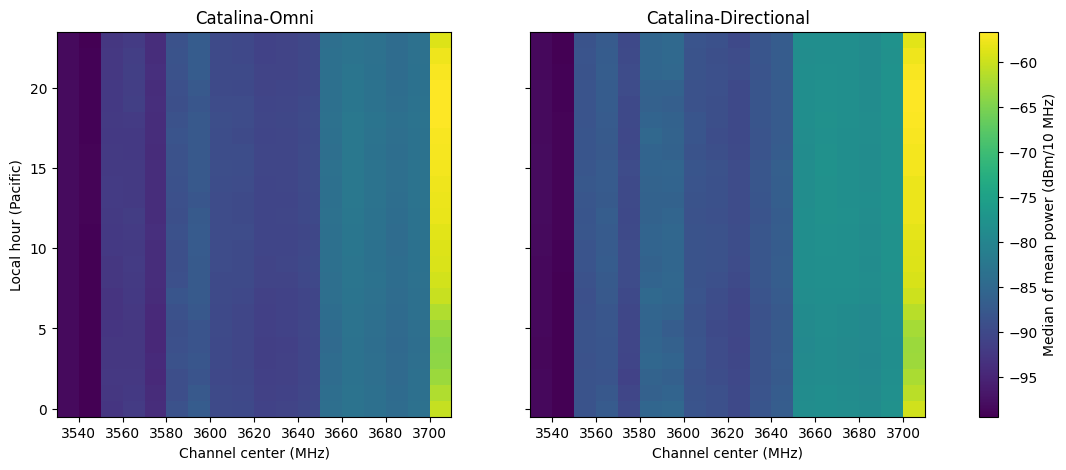

In [3]:
import matplotlib.pyplot as plt

cat = df[df["sensor_name"].str.startswith("Catalina")].copy()
cat["t"] = pd.to_datetime(cat["timestamp"], format="mixed").dt.tz_convert("US/Pacific")
cat["hour"] = cat["t"].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, name in zip(axes, ["Catalina-Omni", "Catalina-Directional"]):
    pivot = (cat[cat["sensor_name"] == name]
             .groupby(["hour", "channel_frequency_mhz"])["mean"].median()
             .unstack())
    im = ax.pcolormesh(pivot.columns, pivot.index, pivot.values, cmap="viridis")
    ax.set_title(name); ax.set_xlabel("Channel center (MHz)")
axes[0].set_ylabel("Local hour (Pacific)")
fig.colorbar(im, ax=axes, label="Median of mean power (dBm/10 MHz)")
plt.show()

In [4]:
cat.groupby(["sensor_name", "channel_frequency_mhz"])["overload"].mean().unstack(0).round(3)

sensor_name,Catalina-Directional,Catalina-Omni
channel_frequency_mhz,,
3535.0,0.012,0.081
3545.0,0.009,0.064
3555.0,0.008,0.060
3565.0,0.009,0.063
3575.0,0.008,0.045
3585.0,0.006,0.033
3595.0,0.005,0.030
3605.0,0.003,0.036
3615.0,0.001,0.036


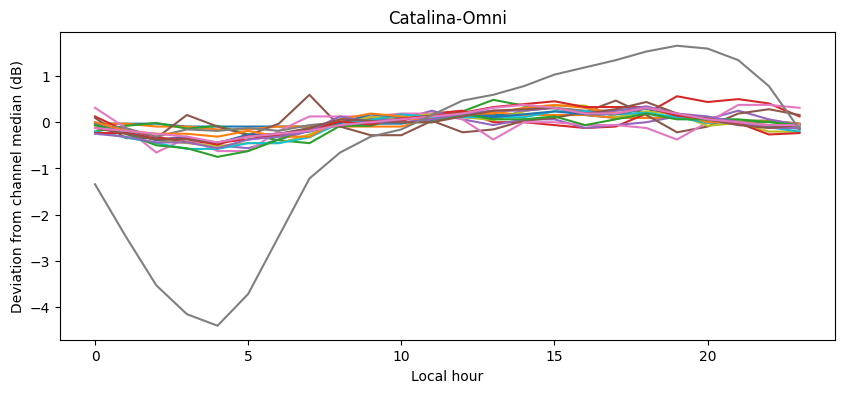

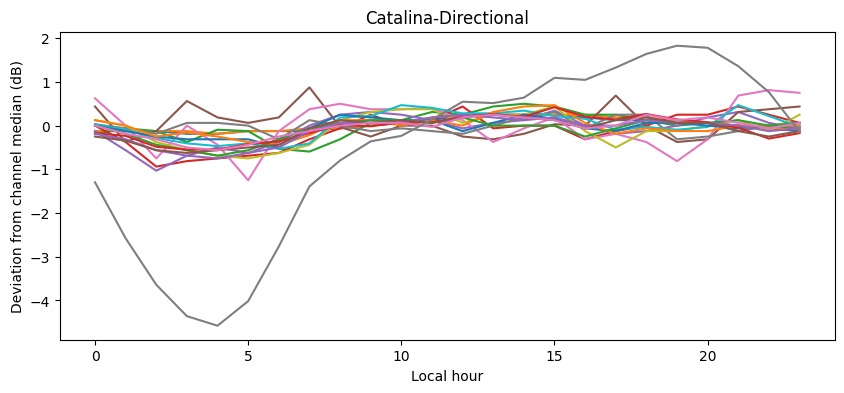

In [5]:
for name in ["Catalina-Omni", "Catalina-Directional"]:
    p = (cat[cat["sensor_name"] == name]
         .groupby(["hour", "channel_frequency_mhz"])["mean"].median().unstack())
    (p - p.median()).plot(figsize=(10, 4), legend=False, title=name)
    plt.ylabel("Deviation from channel median (dB)"); plt.xlabel("Local hour")
    plt.show()

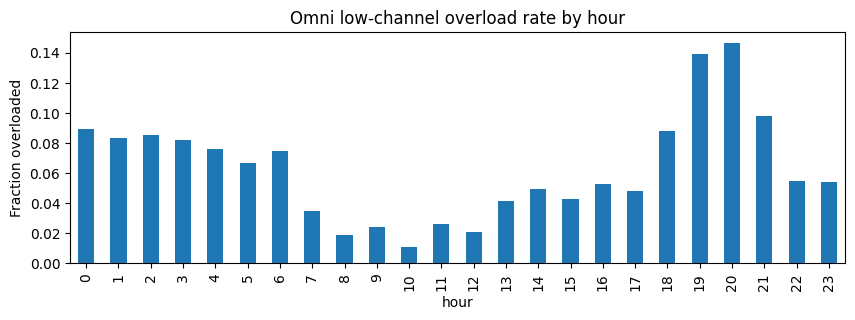

In [6]:
o = cat[(cat["sensor_name"] == "Catalina-Omni") & (cat["channel_frequency_mhz"] <= 3575)]
o.groupby("hour")["overload"].mean().plot(kind="bar", figsize=(10, 3), title="Omni low-channel overload rate by hour")
plt.ylabel("Fraction overloaded"); plt.show()

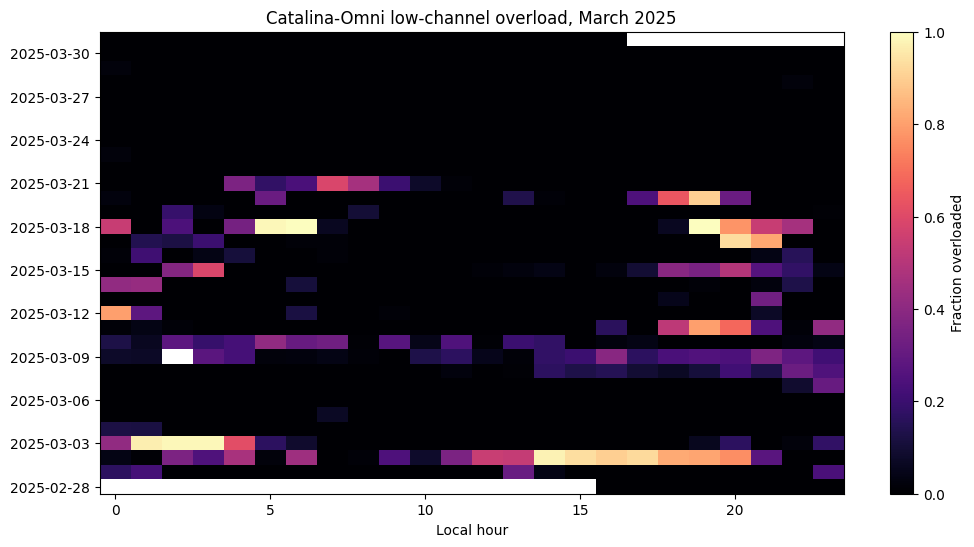

In [7]:
o = o.copy()
o["day"] = o["t"].dt.date
hm = o.groupby(["day", "hour"])["overload"].mean().unstack()
plt.figure(figsize=(12, 6))
plt.pcolormesh(hm.columns, range(len(hm)), hm.values, cmap="magma")
plt.yticks(range(0, len(hm), 3), hm.index[::3])
plt.colorbar(label="Fraction overloaded"); plt.xlabel("Local hour"); plt.title("Catalina-Omni low-channel overload, March 2025")
plt.show()

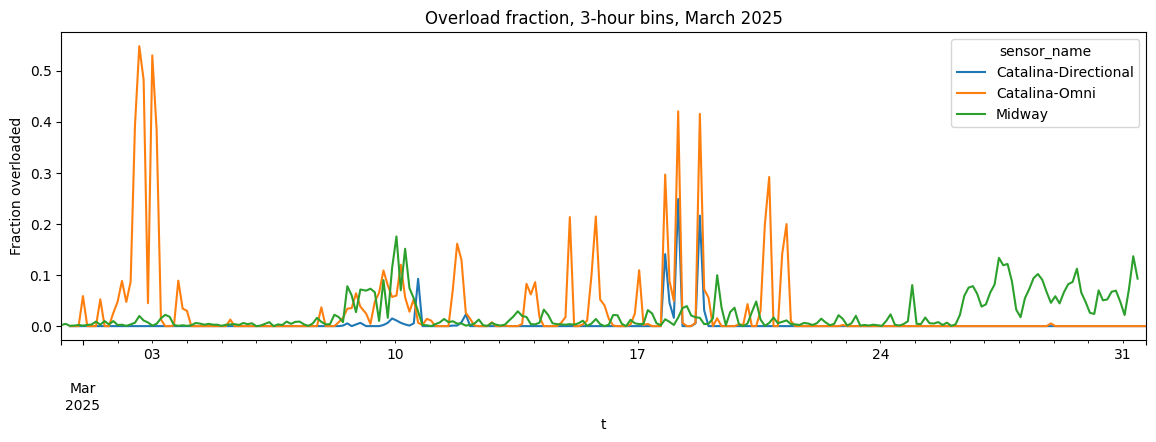

In [8]:

sub = df[df["sensor_name"].isin(["Catalina-Omni", "Catalina-Directional", "Midway"])].copy()
sub["t"] = pd.to_datetime(sub["timestamp"], format="mixed").dt.tz_convert("US/Pacific")
ts = (sub.set_index("t").groupby("sensor_name")["overload"]
        .resample("3h").mean().unstack(0))
ts.plot(figsize=(14, 4), title="Overload fraction, 3-hour bins, March 2025")
plt.ylabel("Fraction overloaded"); plt.show()

In [9]:
from sea_loader import inspect_zip, load_dayblock, plot_pfp
import pandas as pd, matplotlib.pyplot as plt
inspect_zip("data/2025-03-02_Catalina-Omni.zip")

417 entries; first 10:
   2025_3_2_0_11_2189.sigmf
   2025_3_2_0_15_2190.sigmf
   2025_3_2_0_18_2191.sigmf
   2025_3_2_0_1_2186.sigmf
   2025_3_2_0_22_2192.sigmf
   2025_3_2_0_25_2193.sigmf
   2025_3_2_0_27_2194.sigmf
   2025_3_2_0_30_2195.sigmf
   2025_3_2_0_33_2196.sigmf
   2025_3_2_0_38_2197.sigmf


In [10]:
import io, json, lzma, tarfile, zipfile
import numpy as np

z = zipfile.ZipFile("data/2025-03-02_Catalina-Omni.zip")
buf = z.read("2025_3_2_0_11_2189.sigmf")
tar = tarfile.open(fileobj=io.BytesIO(buf))
print("Members:", [m.name for m in tar.getmembers()])

for m in tar.getmembers():
    if m.name.endswith("-meta"):
        meta = json.load(tar.extractfile(m))
        print("Meta keys:", list(meta.keys()))
        print("Num captures:", len(meta.get("captures", [])))
        print("First capture:", meta["captures"][0] if meta.get("captures") else None)
    elif m.name.endswith("-data"):
        raw = tar.extractfile(m).read()
        arr = np.frombuffer(lzma.decompress(raw), dtype=np.float16)
        print("Array size:", arr.size, "(expected 100080)")

Members: ['2025_3_2_0_11_2189.sigmf-meta', '2025_3_2_0_11_2189.sigmf-data']
Meta keys: ['global', 'captures', 'annotations']
Num captures: 18
First capture: {'core:sample_start': 0, 'core:frequency': 3535000000.0, 'core:datetime': '2025-03-02T00:11:59.398Z', 'ntia-sensor:overload': False, 'ntia-sensor:sensor_calibration': {'gain': 30.253, 'temperature': 13.6, 'datetime': '2025-03-01T23:38:43.735Z', 'reference': 'antenna terminal', 'noise_figure': 6.45}, 'ntia-sensor:duration': 4000, 'ntia-sensor:sigan_settings': {'attenuation': 6.0, 'reference_level': -19.0, 'preamp_enable': True}}
Array size: 100098 (expected 100080)


In [11]:
from sea_loader import load_dayblock, plot_pfp
import pandas as pd, matplotlib.pyplot as plt
days = ["2025-03-02", "2025-03-03", "2025-03-18", "2025-03-25"]
raw = pd.concat([load_dayblock(f"data/{d}_Catalina-Omni.zip") for d in days])
raw[["time", "freq_mhz", "overload", "peak_dbm", "rms_dbm", "radar_score", "noise_figure_db"]].head()

data/2025-03-02_Catalina-Omni.zip: 417 sweeps loaded, 0 skipped
data/2025-03-03_Catalina-Omni.zip: 416 sweeps loaded, 0 skipped
data/2025-03-18_Catalina-Omni.zip: 405 sweeps loaded, 0 skipped
data/2025-03-25_Catalina-Omni.zip: 397 sweeps loaded, 0 skipped


,time,freq_mhz,overload,peak_dbm,rms_dbm,radar_score,noise_figure_db
0,2025-03-02 00:11:59.398000+00:00,3535.0,False,-84.8125,-98.004128,4.448710,6.450
1,2025-03-02 00:12:04.008000+00:00,3545.0,False,-86.3750,-98.799438,0.090776,5.796
2,2025-03-02 00:12:08.743000+00:00,3555.0,False,-72.7500,-95.270645,1.069251,5.697
3,2025-03-02 00:12:15.096000+00:00,3565.0,False,-76.0625,-95.651001,4.580025,5.583
4,2025-03-02 00:12:19.892000+00:00,3575.0,False,-76.6875,-95.003685,1.239967,5.547


In [12]:
noise = raw[raw["freq_mhz"] == 3535]
cols = ["pvt_max", "pvt_mean", "pfp_peak_min", "pfp_peak_max", "pfp_peak_mean",
        "pfp_rms_min", "pfp_rms_max", "pfp_rms_mean"]
for c in cols:
    vals = noise[c].apply(lambda a: float(np.mean(a)))
    print(f"{c:15s} (file position)  median level: {vals.median():7.2f} dBm")

pvt_max         (file position)  median level:  -86.50 dBm
pvt_mean        (file position)  median level:  -97.74 dBm
pfp_peak_min    (file position)  median level:  -91.64 dBm
pfp_peak_max    (file position)  median level:  -86.60 dBm
pfp_peak_mean   (file position)  median level:  -89.39 dBm
pfp_rms_min     (file position)  median level:  -98.65 dBm
pfp_rms_max     (file position)  median level:  -97.06 dBm
pfp_rms_mean    (file position)  median level:  -97.74 dBm


In [13]:
low = raw[raw["freq_mhz"] <= 3575]
print(low.groupby("overload")["radar_score"].describe())

           count      mean        std       min       25%       50%       75%  \
overload                                                                        
False     6532.0  6.604125  12.298886  0.000003  0.861817  2.109507  5.991656   
True      1643.0  3.207976   4.311003  0.000215  0.833235  2.055601  4.292286   

                 max  
overload              
False     177.167306  
True      104.825886  


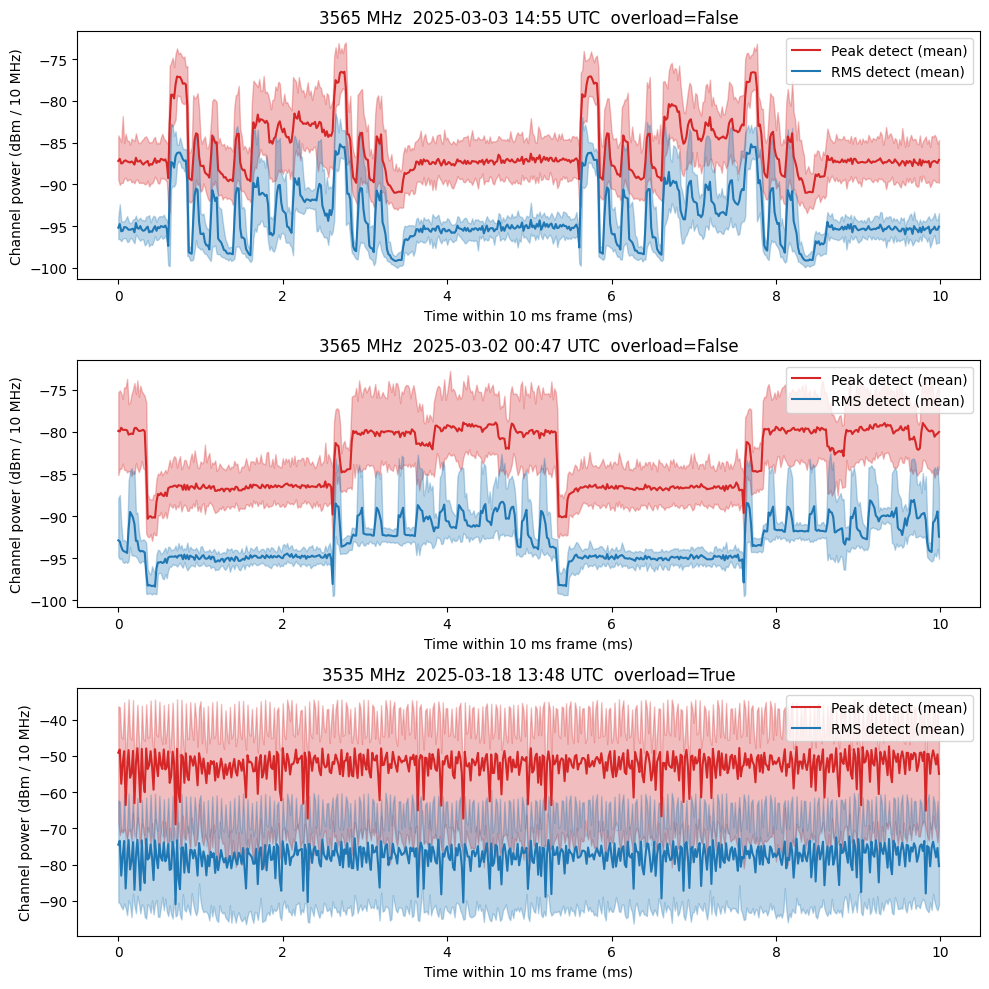

freq_mhz
3535.0    0.201
3545.0    0.206
3555.0    0.199
3565.0    0.204
3575.0    0.195
3585.0    0.140
3595.0    0.130
3605.0    0.138
Name: overload, dtype: float64


In [14]:
fig, ax = plt.subplots(3, 1, figsize=(10, 10))
top = low[low["overload"] == False].sort_values("radar_score").iloc[-2:]
plot_pfp(top.iloc[-1], ax[0]); plot_pfp(top.iloc[-2], ax[1])
plot_pfp(low[low["overload"] == True].sort_values("peak_dbm").iloc[-1], ax[2])
plt.tight_layout(); plt.show()

print(raw.groupby("freq_mhz")["overload"].mean().round(3).head(8))

In [15]:
def dominant_period_ms(pfp_dbm):
    x = 10 ** (np.asarray(pfp_dbm, float) / 10); x -= x.mean()
    spec = np.abs(np.fft.rfft(x))**2
    k = np.argmax(spec[1:100]) + 1          # strongest repetition
    return 10 / k                            # period in ms

low = low.copy()
low["period_ms"] = low["pfp_peak_max"].apply(dominant_period_ms)
print(pd.crosstab(low["period_ms"].round(2), low["overload"]).sort_values(True, ascending=False).head(10))

overload   False  True 
period_ms              
0.11         190    137
10.00         88    123
0.14         149    114
0.19         132    106
1.00          91    100
0.16         131     93
0.10          88     82
0.23         100     72
0.24          93     67
0.12         142     63


In [16]:
def period_and_strength(pfp_dbm):
    x = 10 ** (np.asarray(pfp_dbm, float) / 10); x -= x.mean()
    spec = np.abs(np.fft.rfft(x))**2
    k = np.argmax(spec[1:100]) + 1
    return 10 / k, spec[k] / np.median(spec[1:100])

low[["period_ms", "prominence"]] = low["pfp_peak_max"].apply(lambda a: pd.Series(period_and_strength(a)))
strong = low[(low["prominence"] > 20) & (low["peak_dbm"] > -80)]
print(len(strong), "of", len(low), "sweeps have a clear periodic signal")
print(pd.crosstab([strong["freq_mhz"], strong["period_ms"].round(2)], strong["overload"]).head(20))

3569 of 8175 sweeps have a clear periodic signal
overload            False  True 
freq_mhz period_ms              
3535.0   0.10           0      9
         0.11           0     14
         0.12           0      6
         0.13           0      3
         0.14           1      9
         0.15           0      3
         0.16           0      3
         0.17           0      1
         0.23           1      1
         0.29           0      1
         0.31           0      1
         0.48           0      1
         2.00           0      1
         2.50          16      2
         5.00           1      5
         10.00          3     17
3545.0   0.10           0      7
         0.11           0     14
         0.12           0      5
         0.13           0      7
